# YOLO Prediction Tester

This notebook selects a random image from the training dataset, runs YOLO detection (benchmarking model loading vs. pure inference time), and renders the annotated result inline using matplotlib.

In [1]:
import random
import time
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
from yolo_draw import draw_yolo_boxes

In [2]:
# Configuration
WEIGHTS_PATH = "runs/detect/runs/elephant/yolo26n/weights/best.pt"
TEST_IMAGES_DIR = Path("elephant_dataset/images/test")

In [3]:
# Pick a random testing image
images = list(TEST_IMAGES_DIR.glob("*.jpg"))
if not images:
    raise FileNotFoundError(f"No images found in {TEST_IMAGES_DIR}")

sample_path = random.choice(images)
print(f"Using sample image: {sample_path}")

frame = cv2.imread(str(sample_path))
if frame is None:
    raise RuntimeError(f"Failed to load image: {sample_path}")

Using sample image: elephant_dataset\images\test\00001529.jpg


In [4]:
# First pass (model loading + inference)
t0 = time.perf_counter()
annotated = draw_yolo_boxes(frame, WEIGHTS_PATH, conf=0.4, box_color=(0, 0, 255))
t1 = time.perf_counter()
print(f"First call (includes model load): {(t1 - t0) * 1000:.1f} ms")

First call (includes model load): 474.2 ms


In [5]:
# Second pass (inference only, model weights are cached)
t2 = time.perf_counter()
annotated = draw_yolo_boxes(frame, WEIGHTS_PATH, conf=0.4, box_color=(0, 0, 255))
t3 = time.perf_counter()
print(f"Second call (inference + draw only): {(t3 - t2) * 1000:.1f} ms")
print(f"Effective FPS at that speed: {1 / (t3 - t2):.1f}")

Second call (inference + draw only): 14.0 ms
Effective FPS at that speed: 71.6


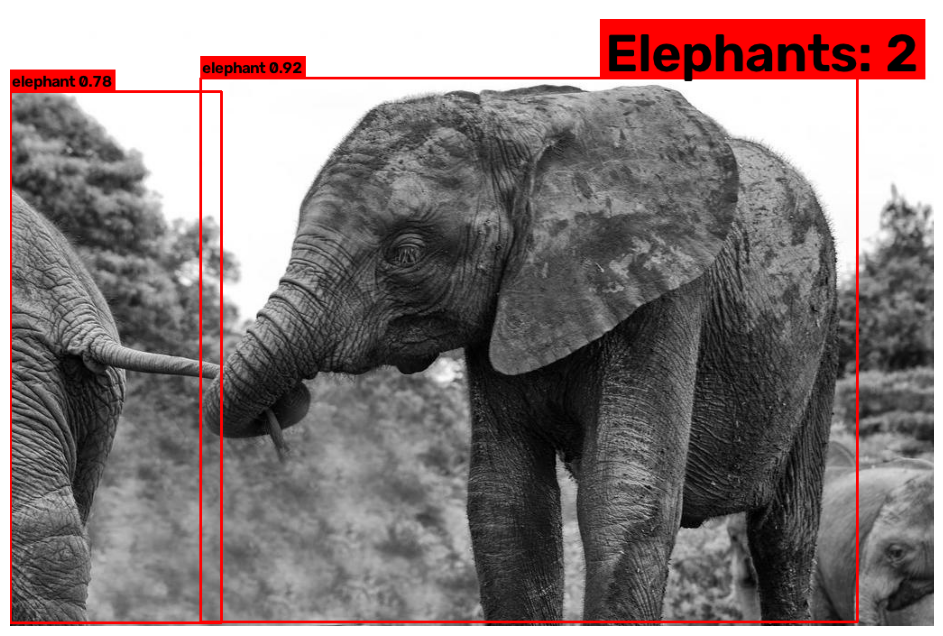

In [6]:
# Convert BGR to RGB for matplotlib
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(annotated_rgb)
plt.axis('off')
plt.show()